# Chest X-Ray Pneumonia Classification

Binary classification of chest X-ray images (Normal vs Pneumonia).
We compare a lightweight CNN trained from scratch against a fine-tuned ResNet18,
and use Grad-CAM to interpret model decisions.

**Dataset:** Chest X-Ray Images (Pneumonia) — Kaggle / Paul Mooney  
5,863 labeled JPEG images, split into train / val / test directories.


## 1. Environment & Data


In [1]:
import sys, torch, torchvision, sklearn, cv2
print(f"Python  : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"OpenCV  : {cv2.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Python  : 3.12.12
PyTorch : 2.10.0+cu128
Torchvision: 0.25.0+cu128
scikit-learn: 1.6.1
OpenCV  : 4.13.0
GPU available: True
GPU: Tesla T4


In [2]:
!pip install -q kagglehub

import kagglehub
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Dataset path:", path)


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset path: /kaggle/input/chest-xray-pneumonia


## 2. Imports


In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_recall_curve,
)

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


## 3. Data Overview


In [5]:
DATA_DIR = Path("/kaggle/input/chest-xray-pneumonia/chest_xray")
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR   = DATA_DIR / "val"
TEST_DIR  = DATA_DIR / "test"

for split_name, split_dir in [("Train", TRAIN_DIR), ("Val", VAL_DIR), ("Test", TEST_DIR)]:
    classes = sorted([d.name for d in split_dir.iterdir() if d.is_dir()])
    counts  = {c: len(list((split_dir / c).glob("*"))) for c in classes}
    total   = sum(counts.values())
    ratio   = counts["PNEUMONIA"] / counts["NORMAL"]
    print(f"{split_name:5s} | {counts} | Total: {total} | P/N ratio: {ratio:.2f}")


Train | {'NORMAL': 1341, 'PNEUMONIA': 3875} | Total: 5216 | P/N ratio: 2.89
Val   | {'NORMAL': 8, 'PNEUMONIA': 8} | Total: 16 | P/N ratio: 1.00
Test  | {'NORMAL': 234, 'PNEUMONIA': 390} | Total: 624 | P/N ratio: 1.67


## 4. Exploratory Data Analysis

The dataset is heavily imbalanced (~3:1 Pneumonia-to-Normal in training).
The val split has only 16 images and will be merged into training.
All evaluation is done on the held-out test set.


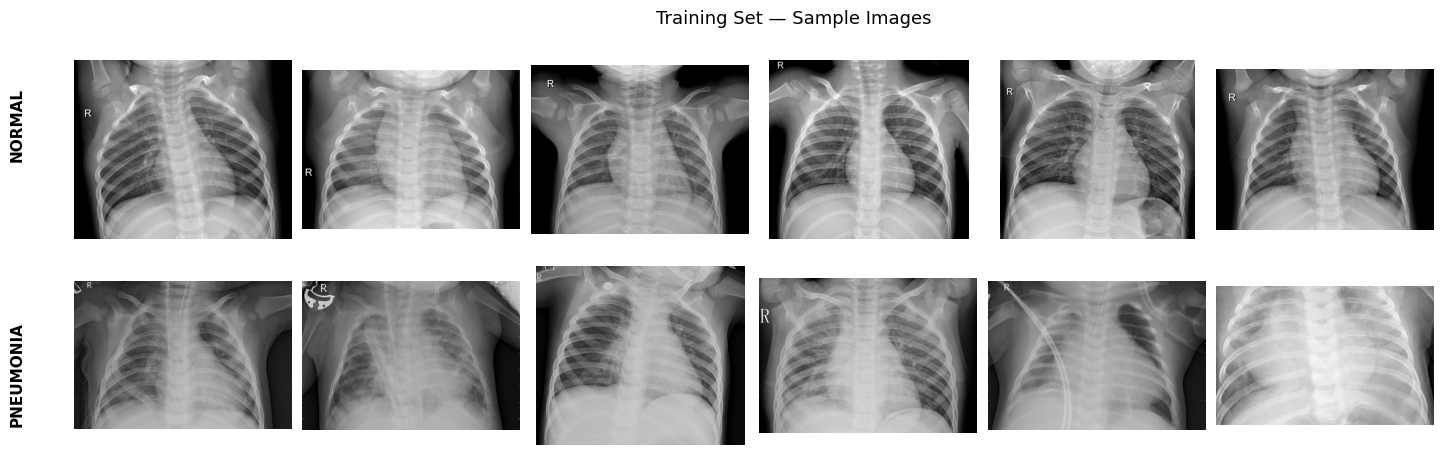

In [10]:
fig, axes = plt.subplots(2, 6, figsize=(16, 5))

for row, class_name in enumerate(["NORMAL", "PNEUMONIA"]):
    class_dir = TRAIN_DIR / class_name
    sample_paths = random.sample(list(class_dir.iterdir()), 6)
    for col, img_path in enumerate(sample_paths):
        img = Image.open(img_path).convert("L")
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
    # label with fig.text — positioned outside axes
    fig.text(
        0.01, 0.75 - row * 0.5,
        class_name,
        va="center", ha="left",
        fontsize=11, fontweight="bold",
        rotation=90
    )

plt.suptitle("Training Set — Sample Images", fontsize=13)
plt.subplots_adjust(left=0.05, wspace=0.05, hspace=0.15)
plt.show()


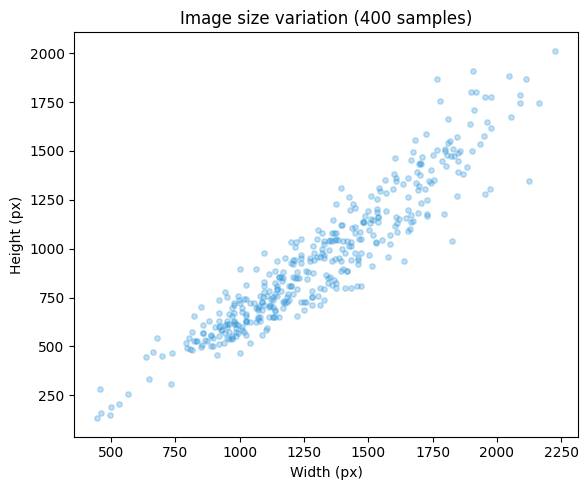

Width  — min:  446, max: 2226, median: 1280
Height — min:  132, max: 2013, median:  888


In [12]:
widths, heights = [], []
sample_imgs = random.sample(list(TRAIN_DIR.rglob("*.jpeg")), 400)

for p in sample_imgs:
    with Image.open(p) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(widths, heights, alpha=0.3, s=15, color="#3498db")
ax.set_xlabel("Width (px)")
ax.set_ylabel("Height (px)")
ax.set_title("Image size variation (400 samples)")
plt.tight_layout()
plt.show()

print(f"Width  — min: {min(widths):4d}, max: {max(widths):4d}, median: {int(np.median(widths)):4d}")
print(f"Height — min: {min(heights):4d}, max: {max(heights):4d}, median: {int(np.median(heights)):4d}")


## 5. Data Preprocessing

Images are resized to 224×224 (ResNet18 standard input).
Training receives light augmentation: horizontal flip, +-10° rotation, small
brightness/contrast jitter — conservative enough not to distort diagnostic features.

The validation split (16 images) is merged into training.
Class imbalance is handled with WeightedRandomSampler so each batch sees
a balanced draw.



In [16]:
IMG_SIZE   = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),   # ensure 3-channel for ResNet
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Val split has only 16 images — merge into training
from torch.utils.data import ConcatDataset

train_base = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_base   = datasets.ImageFolder(VAL_DIR,   transform=train_transform)
train_dataset = ConcatDataset([train_base, val_base])
test_dataset  = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

# WeightedRandomSampler — ConcatDataset has no .targets, build weights manually
all_labels = train_base.targets + val_base.targets
class_counts = Counter(all_labels)
weights = [1.0 / class_counts[lbl] for lbl in all_labels]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_names = train_base.classes
print(f"Classes : {class_names}")
print(f"Train   : {len(train_dataset)} images")
print(f"Test    : {len(test_dataset)} images")


Classes : ['NORMAL', 'PNEUMONIA']
Train   : 5232 images
Test    : 624 images


In [17]:
# Build weighted sampler from merged targets
all_targets = train_base.targets + val_base.targets
class_counts = Counter(all_targets)
class_weights = {c: 1.0 / n for c, n in class_counts.items()}
sample_weights = [class_weights[t] for t in all_targets]

sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True)

print(f"Class counts (raw):     {dict(class_counts)}")
print(f"Sample weight per class: { {c: f'{w:.6f}' for c, w in class_weights.items()} }")
print(f"Train batches: {len(train_loader)} | Test batches: {len(test_loader)}")


Class counts (raw):     {0: 1349, 1: 3883}
Sample weight per class: {0: '0.000741', 1: '0.000258'}
Train batches: 164 | Test batches: 20


## 6. Baseline CNN

3-block conv net to set a performance reference.


In [18]:
class XRayClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.head(self.features(x))

model = XRayClassifier().to(device)
params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {params:,}")

# sanity check — forward pass on dummy input
with torch.no_grad():
    dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE).to(device)
    out = model(dummy)
print(f"Output shape: {out.shape}")  # expected: torch.Size([1, 1])


Parameters: 93,825
Output shape: torch.Size([1, 1])


In [25]:
import time

def train_model(model, train_loader, test_loader,
                epochs=50, lr=1e-3, save_path="checkpoint.pt", patience=7):

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

    history = {k: [] for k in
               ["train_loss","test_loss","train_acc","test_acc","train_f1","test_f1","test_auc"]}
    best_auc, no_improve = 0.0, 0

    hdr = f"{'Ep':>4} | {'TrLoss':>7} {'TrAcc':>6} {'TrF1':>6} | {'TeLoss':>7} {'TeAcc':>6} {'TeF1':>6} {'TeAUC':>6} | {'LR':>8} {'Time':>6}"
    print(hdr)
    print("-" * len(hdr))

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        # ------- train -------
        model.train()
        run_loss, tr_true, tr_pred = 0.0, [], []
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.float().to(device)
            optimizer.zero_grad()
            logits = model(imgs).squeeze(1)
            loss   = criterion(logits, lbls)
            loss.backward()
            optimizer.step()

            run_loss += loss.item() * imgs.size(0)
            probs = torch.sigmoid(logits).detach().cpu()
            tr_pred.extend((probs > 0.5).long().tolist())
            tr_true.extend(lbls.cpu().long().tolist())

        tr_loss = run_loss / len(tr_true)
        tr_acc  = (np.array(tr_pred) == np.array(tr_true)).mean()
        tr_f1   = f1_score(tr_true, tr_pred, zero_division=0)

        # ------- eval -------
        model.eval()
        run_loss, te_true, te_pred, te_prob = 0.0, [], [], []
        with torch.no_grad():
            for imgs, lbls in test_loader:
                imgs, lbls = imgs.to(device), lbls.float().to(device)
                logits = model(imgs).squeeze(1)
                run_loss += criterion(logits, lbls).item() * imgs.size(0)
                probs = torch.sigmoid(logits).cpu()
                te_prob.extend(probs.tolist())
                te_pred.extend((probs > 0.5).long().tolist())
                te_true.extend(lbls.cpu().long().tolist())

        te_loss = run_loss / len(te_true)
        te_acc  = (np.array(te_pred) == np.array(te_true)).mean()
        te_f1   = f1_score(te_true, te_pred, zero_division=0)
        te_auc  = roc_auc_score(te_true, te_prob)
        lr_now  = optimizer.param_groups[0]["lr"]
        elapsed = time.time() - t0

        scheduler.step(te_loss)

        for k, v in zip(history.keys(),
                        [tr_loss, te_loss, tr_acc, te_acc, tr_f1, te_f1, te_auc]):
            history[k].append(v)

        marker = ""
        if te_auc > best_auc:
            best_auc, no_improve = te_auc, 0
            torch.save(model.state_dict(), save_path)
            marker = "  [saved]"
        else:
            no_improve += 1

        print(f"{epoch:>4} | {tr_loss:>7.4f} {tr_acc:>6.3f} {tr_f1:>6.3f} | "
              f"{te_loss:>7.4f} {te_acc:>6.3f} {te_f1:>6.3f} {te_auc:>6.3f} | "
              f"{lr_now:>8.1e} {elapsed:>5.1f}s{marker}")

        if no_improve >= patience:
            print(f"\nEarly stopping — no AUC gain for {patience} epochs.")
            break

    print(f"\nBest AUC: {best_auc:.4f}  →  {save_path}")
    return history


**Training log columns:** Ep = epoch | Tr = Train, Te = Test | | F1 = F1-score (pneumonia class)


In [26]:
cnn_history = train_model(
    model, train_loader, test_loader,
    epochs=50, lr=1e-3,
    save_path="cnn_best.pt",
    patience=7,
)


  Ep |  TrLoss  TrAcc   TrF1 |  TeLoss  TeAcc   TeF1  TeAUC |       LR   Time
-----------------------------------------------------------------------------
   1 |  0.3175  0.879  0.875 |  0.5961  0.756  0.808  0.803 |  1.0e-03 161.9s  [saved]
   2 |  0.3114  0.878  0.877 |  0.4936  0.784  0.822  0.841 |  1.0e-03 173.0s  [saved]
   3 |  0.2911  0.890  0.885 |  0.4497  0.798  0.852  0.874 |  1.0e-03 177.3s  [saved]
   4 |  0.3052  0.874  0.873 |  0.5998  0.761  0.798  0.819 |  1.0e-03 171.8s
   5 |  0.2767  0.894  0.892 |  0.5326  0.769  0.790  0.879 |  1.0e-03 164.2s  [saved]
   6 |  0.2812  0.889  0.888 |  0.4923  0.795  0.848  0.863 |  1.0e-03 151.3s
   7 |  0.2714  0.892  0.891 |  0.4001  0.832  0.866  0.902 |  1.0e-03 152.0s  [saved]
   8 |  0.2588  0.903  0.903 |  0.5186  0.792  0.841  0.849 |  1.0e-03 154.3s
   9 |  0.2685  0.894  0.894 |  0.7519  0.724  0.734  0.868 |  1.0e-03 154.2s
  10 |  0.2827  0.895  0.894 |  1.3437  0.678  0.795  0.822 |  1.0e-03 156.0s
  11 |  0.2651  0.9

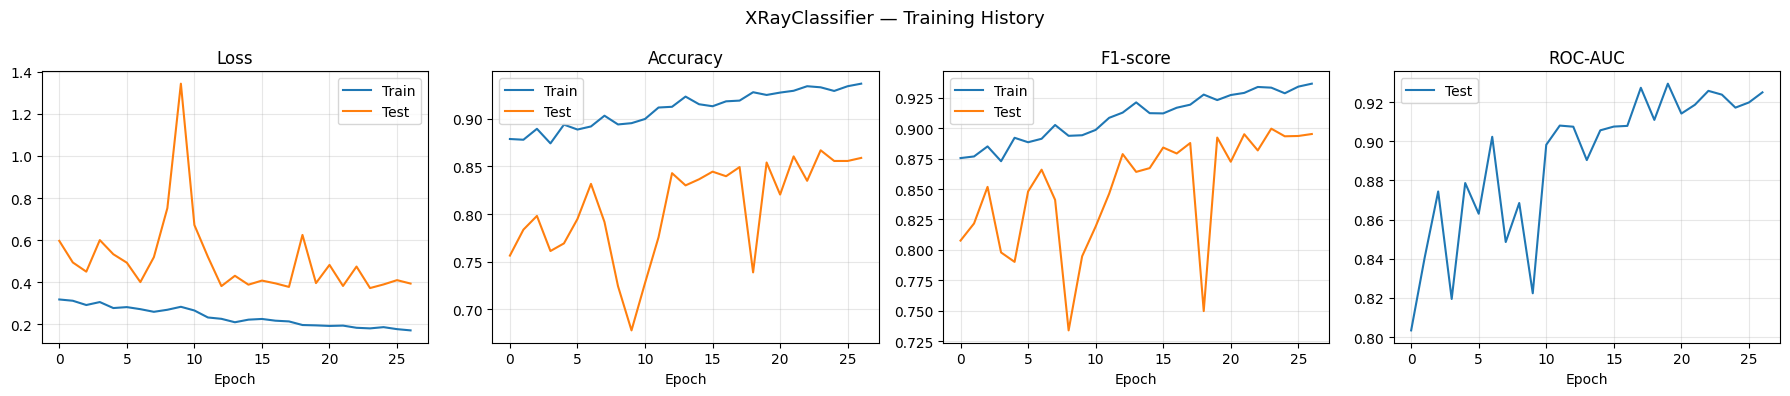

In [27]:
def plot_history(history, title):
    metrics = [
        ("train_loss",  "test_loss",  "Loss"),
        ("train_acc",   "test_acc",   "Accuracy"),
        ("train_f1",    "test_f1",    "F1-score"),
        (None,          "test_auc",   "ROC-AUC"),
    ]
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, (tr_key, te_key, label) in zip(axes, metrics):
        if tr_key:
            ax.plot(history[tr_key], label="Train")
        ax.plot(history[te_key], label="Test")
        ax.set_xlabel("Epoch")
        ax.set_title(label)
        ax.legend()
        ax.grid(alpha=0.3)
    fig.suptitle(title, fontsize=13)
    fig.tight_layout()
    plt.show()

plot_history(cnn_history, "XRayClassifier — Training History")


## 7. Transfer Learning — ResNet18

We compare two fine-tuning strategies:
- **Frozen** — only the classification head is trainable, all conv layers stay fixed
- **Partial fine-tune** — last two residual blocks (layer3, layer4) and head are trainable


In [28]:
def build_resnet(freeze="all"):
    resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    if freeze == "all":
        for param in resnet.parameters():
            param.requires_grad = False
    elif freeze == "partial":
        for name, param in resnet.named_parameters():
            if "layer3" not in name and "layer4" not in name:
                param.requires_grad = False

    resnet.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(resnet.fc.in_features, 1),
    )
    return resnet.to(device)

def param_summary(model, label):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"{label:20s} — trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

resnet_frozen  = build_resnet(freeze="all")
resnet_partial = build_resnet(freeze="partial")

param_summary(resnet_frozen,  "ResNet18 (frozen)")
param_summary(resnet_partial, "ResNet18 (partial)")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 197MB/s]


ResNet18 (frozen)    — trainable: 513 / 11,177,025 (0.0%)
ResNet18 (partial)   — trainable: 10,493,953 / 11,177,025 (93.9%)


  Ep |  TrLoss  TrAcc   TrF1 |  TeLoss  TeAcc   TeF1  TeAUC |       LR   Time
-----------------------------------------------------------------------------
   1 |  0.4316  0.804  0.800 |  0.3053  0.886  0.906  0.953 |  1.0e-03 149.3s  [saved]
   2 |  0.2751  0.897  0.898 |  0.2689  0.902  0.921  0.955 |  1.0e-03 146.0s  [saved]
   3 |  0.2541  0.901  0.899 |  0.2707  0.901  0.919  0.954 |  1.0e-03 149.8s
   4 |  0.2383  0.908  0.906 |  0.2579  0.904  0.925  0.955 |  1.0e-03 148.3s  [saved]
   5 |  0.2390  0.909  0.907 |  0.2516  0.905  0.925  0.956 |  1.0e-03 150.2s  [saved]
   6 |  0.2263  0.913  0.913 |  0.2582  0.899  0.921  0.954 |  1.0e-03 149.1s
   7 |  0.2324  0.909  0.907 |  0.2643  0.902  0.924  0.955 |  1.0e-03 150.7s
   8 |  0.2400  0.905  0.904 |  0.2618  0.905  0.927  0.955 |  1.0e-03 148.4s
   9 |  0.2169  0.911  0.909 |  0.2587  0.905  0.926  0.955 |  1.0e-03 149.3s
  10 |  0.2287  0.910  0.908 |  0.2593  0.905  0.926  0.954 |  5.0e-04 150.3s
  11 |  0.2160  0.914  0.916

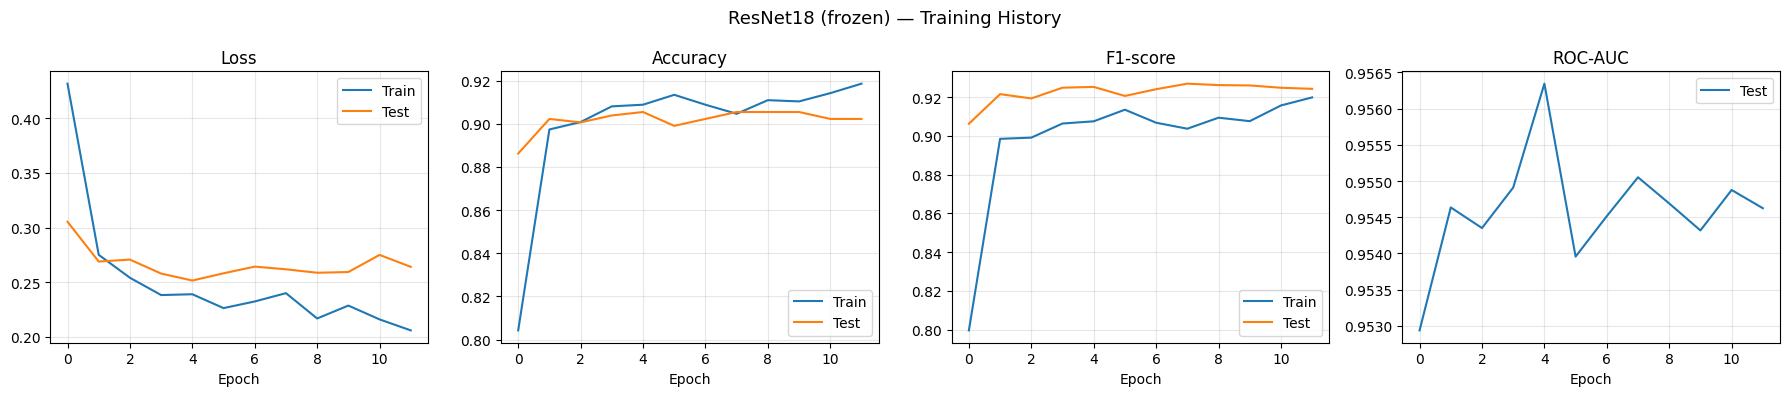

In [29]:
resnet_frozen = build_resnet(freeze="all")

frozen_history = train_model(
    resnet_frozen, train_loader, test_loader,
    epochs=50, lr=1e-3,
    save_path="resnet_frozen.pt",
    patience=7,
)
plot_history(frozen_history, "ResNet18 (frozen) — Training History")


In [30]:
resnet_finetuned = build_resnet(freeze="partial")
trainable = sum(p.numel() for p in resnet_finetuned.parameters() if p.requires_grad)
total = sum(p.numel() for p in resnet_finetuned.parameters())
print(f"Fine-tuned — trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")


Fine-tuned — trainable: 10,493,953 / 11,177,025 (93.9%)


  Ep |  TrLoss  TrAcc   TrF1 |  TeLoss  TeAcc   TeF1  TeAUC |       LR   Time
-----------------------------------------------------------------------------
   1 |  0.1239  0.952  0.952 |  0.2765  0.917  0.937  0.973 |  1.0e-04 149.1s  [saved]
   2 |  0.0551  0.980  0.981 |  0.5336  0.864  0.902  0.961 |  1.0e-04 150.5s
   3 |  0.0527  0.981  0.981 |  0.4041  0.889  0.918  0.965 |  1.0e-04 147.6s
   4 |  0.0352  0.987  0.987 |  0.7297  0.822  0.875  0.960 |  1.0e-04 150.7s
   5 |  0.0281  0.990  0.990 |  0.5861  0.846  0.889  0.954 |  1.0e-04 149.8s
   6 |  0.0240  0.992  0.992 |  0.4930  0.877  0.910  0.967 |  5.0e-05 149.1s
   7 |  0.0149  0.996  0.996 |  0.4811  0.880  0.912  0.971 |  5.0e-05 148.9s
   8 |  0.0138  0.996  0.996 |  0.7243  0.829  0.879  0.962 |  5.0e-05 150.5s

Early stopping — no AUC gain for 7 epochs.

Best AUC: 0.9730  →  resnet_finetuned.pt


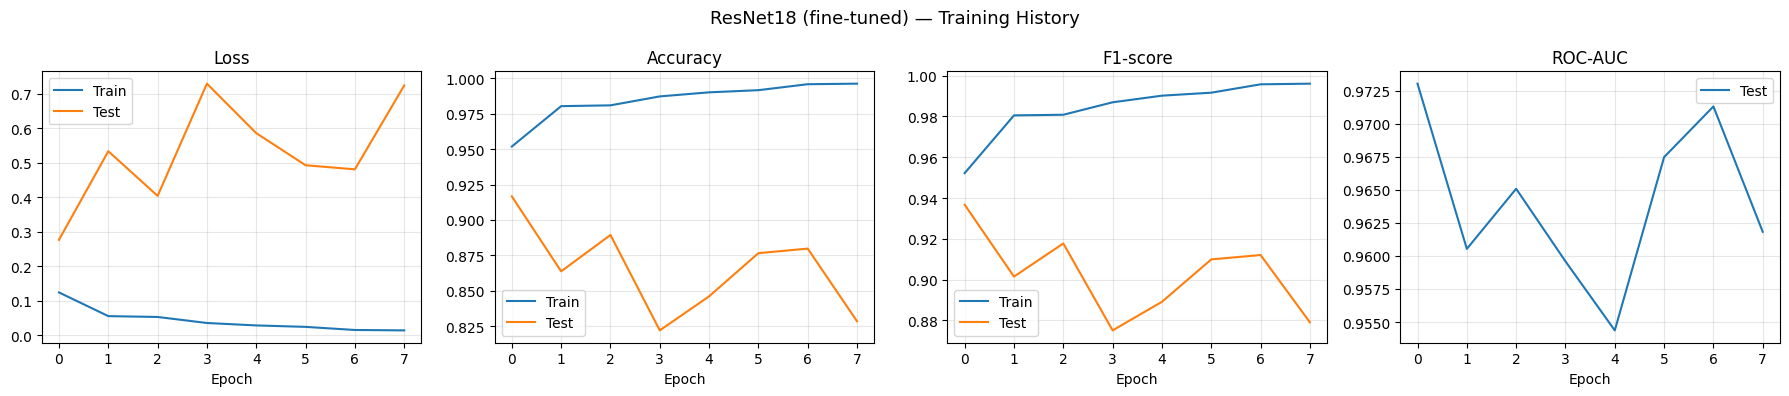

In [31]:
finetuned_history = train_model(
    resnet_finetuned, train_loader, test_loader,
    epochs=50, lr=1e-4,
    save_path="resnet_finetuned.pt",
    patience=7,
)
plot_history(finetuned_history, "ResNet18 (fine-tuned) — Training History")

## 8. Evaluation


In [32]:
def evaluate(model, loader):
    model.eval()
    all_labels, all_probs = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            probs  = torch.sigmoid(model(images).squeeze(1)).cpu().numpy()
            all_labels.extend(labels.numpy())
            all_probs.extend(probs)
    labels = np.array(all_labels)
    probs  = np.array(all_probs)
    preds  = (probs > 0.5).astype(int)
    return labels, preds, probs

# Load best checkpoints
model.load_state_dict(torch.load("cnn_best.pt",           map_location=device))
resnet_frozen.load_state_dict(torch.load("resnet_frozen.pt",  map_location=device))
resnet_finetuned.load_state_dict(torch.load("resnet_finetuned.pt", map_location=device))

cnn_labels,    cnn_preds,    cnn_probs    = evaluate(model,           test_loader)
frozen_labels, frozen_preds, frozen_probs = evaluate(resnet_frozen,   test_loader)
ft_labels,     ft_preds,     ft_probs     = evaluate(resnet_finetuned, test_loader)

print("Evaluation done.")


Evaluation done.


In [33]:
class_names = test_dataset.classes

print(f"=== XRayClassifier (CNN)  (AUC: {roc_auc_score(cnn_labels, cnn_probs):.4f}) ===")
print(classification_report(cnn_labels, cnn_preds, target_names=class_names))

print(f"=== ResNet18 (frozen)  (AUC: {roc_auc_score(frozen_labels, frozen_probs):.4f}) ===")
print(classification_report(frozen_labels, frozen_preds, target_names=class_names))

print(f"=== ResNet18 (fine-tuned)  (AUC: {roc_auc_score(ft_labels, ft_probs):.4f}) ===")
print(classification_report(ft_labels, ft_preds, target_names=class_names))


=== XRayClassifier (CNN)  (AUC: 0.9294) ===
              precision    recall  f1-score   support

      NORMAL       0.92      0.67      0.77       234
   PNEUMONIA       0.83      0.97      0.89       390

    accuracy                           0.85       624
   macro avg       0.88      0.82      0.83       624
weighted avg       0.86      0.85      0.85       624

=== ResNet18 (frozen)  (AUC: 0.9563) ===
              precision    recall  f1-score   support

      NORMAL       0.89      0.85      0.87       234
   PNEUMONIA       0.91      0.94      0.93       390

    accuracy                           0.91       624
   macro avg       0.90      0.90      0.90       624
weighted avg       0.91      0.91      0.91       624

=== ResNet18 (fine-tuned)  (AUC: 0.9730) ===
              precision    recall  f1-score   support

      NORMAL       0.97      0.80      0.88       234
   PNEUMONIA       0.89      0.99      0.94       390

    accuracy                           0.92       62

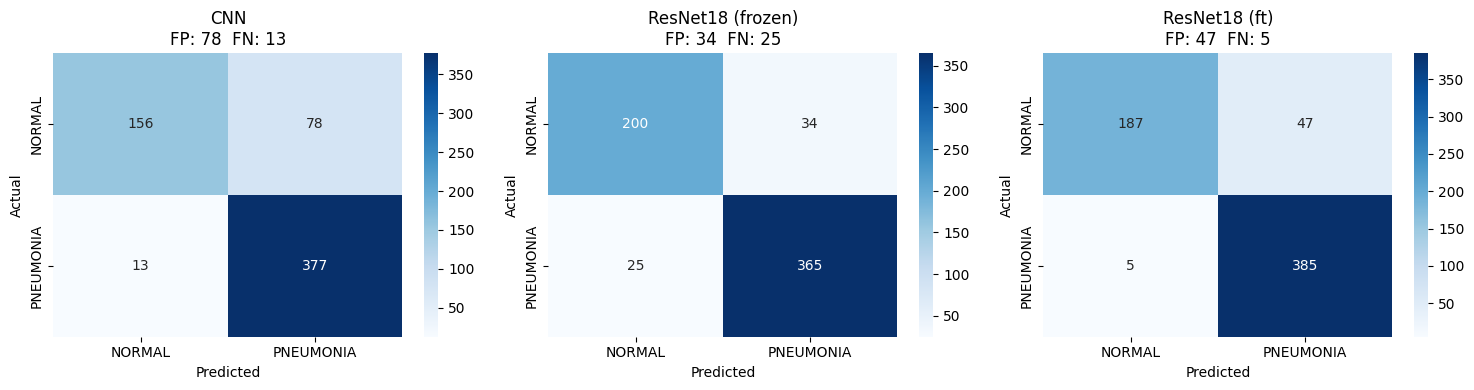

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models_eval = [
    ("CNN",               cnn_labels,    cnn_preds),
    ("ResNet18 (frozen)", frozen_labels, frozen_preds),
    ("ResNet18 (ft)",     ft_labels,     ft_preds),
]

for ax, (name, labels, preds) in zip(axes, models_eval):
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{name}\nFP: {fp}  FN: {fn}")

plt.tight_layout()
plt.show()


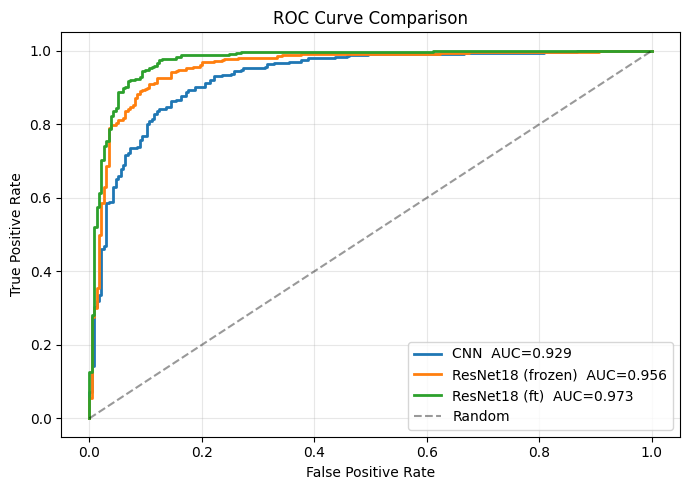

In [35]:
fig, ax = plt.subplots(figsize=(7, 5))

for name, labels, probs in [
    ("CNN",               cnn_labels,    cnn_probs),
    ("ResNet18 (frozen)", frozen_labels, frozen_probs),
    ("ResNet18 (ft)",     ft_labels,     ft_probs),
]:
    fpr, tpr, _ = roc_curve(labels, probs)
    auc = roc_auc_score(labels, probs)
    ax.plot(fpr, tpr, linewidth=2, label=f"{name}  AUC={auc:.3f}")

ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 9. Grad-CAM

Grad-CAM highlights which regions of the image the model focuses on when making predictions. This is useful for checking if the model learns clinically relevant patterns instead of artifacts.


In [36]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None

        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, "activations", o.detach())
        )
        target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, "gradients", go[0].detach())
        )

    def generate(self, input_tensor):
        self.model.eval()
        inp = input_tensor.clone().requires_grad_(True)
        out = self.model(inp)
        self.model.zero_grad()
        out.squeeze().backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = torch.relu((weights * self.activations).sum(dim=1)).squeeze().cpu().numpy()
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

gradcam = GradCAM(resnet_frozen, resnet_frozen.layer4[-1])
print("GradCAM ready — target: resnet_frozen.layer4[-1]")


GradCAM ready — target: resnet_frozen.layer4[-1]


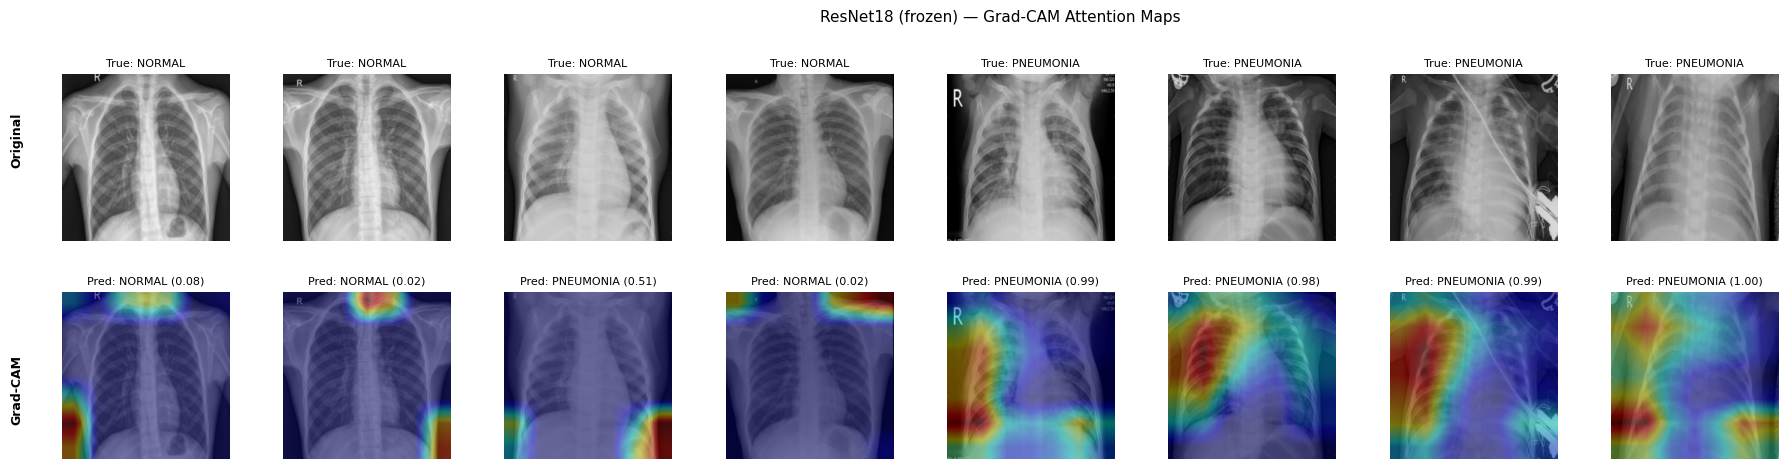

In [44]:
inv_norm = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225],
)

gradcam = GradCAM(resnet_finetuned, resnet_finetuned.layer4[-1].conv2)

normal_idx    = [i for i, (_, l) in enumerate(test_dataset) if l == 0]
pneumonia_idx = [i for i, (_, l) in enumerate(test_dataset) if l == 1]
selected = random.sample(normal_idx, 4) + random.sample(pneumonia_idx, 4)

fig, axes = plt.subplots(2, 8, figsize=(20, 5))

for i, idx in enumerate(selected):
    image, label = test_dataset[idx]
    inp = image.unsqueeze(0).to(device)
    cam = gradcam.generate(inp)

    img        = np.clip(inv_norm(image).permute(1, 2, 0).numpy(), 0, 1)
    cam_resized = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap    = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap    = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    overlay    = 0.5 * img + 0.4 * heatmap

    with torch.no_grad():
        prob = torch.sigmoid(resnet_frozen(inp).squeeze()).item()

    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].set_title(f"True: {class_names[label]}", fontsize=8)
    axes[0, i].axis("off")

    axes[1, i].imshow(overlay)
    axes[1, i].set_title(f"Pred: {class_names[int(prob>0.5)]} ({prob:.2f})", fontsize=8)
    axes[1, i].axis("off")

# row labels
fig.text(0.005, 0.75, "Original",  va="center", ha="left", fontsize=9, fontweight="bold", rotation=90)
fig.text(0.005, 0.25, "Grad-CAM", va="center", ha="left", fontsize=9, fontweight="bold", rotation=90)
plt.suptitle("ResNet18 (frozen) — Grad-CAM Attention Maps", fontsize=11, y=1.01)
plt.subplots_adjust(left=0.02, wspace=0.05, hspace=0.3)
plt.show()


## 10. Error Analysis


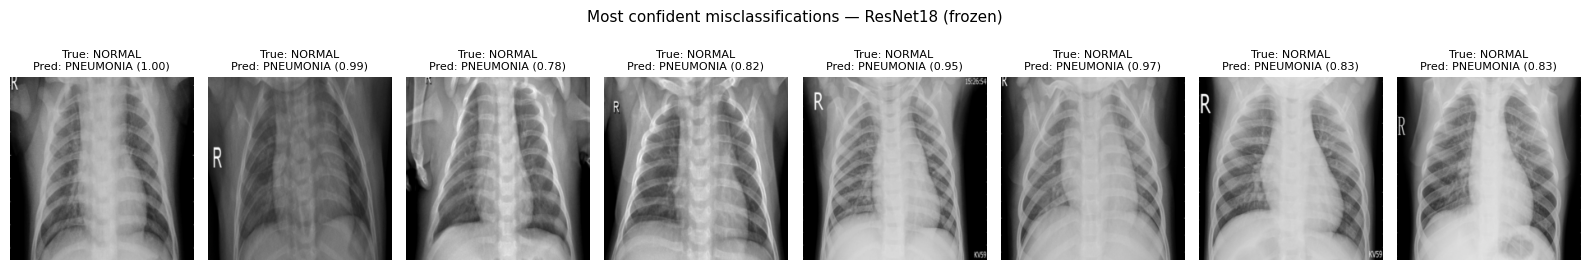

Total errors: 52/624 (8.3%)
  NORMAL: 34/234 wrong (14.5%)
  PNEUMONIA: 25/390 wrong (6.4%)


In [45]:
wrong      = np.where(ft_labels != ft_preds)[0]
confidence = np.abs(ft_probs[wrong] - 0.5)
worst      = wrong[np.argsort(-confidence)][:8]

fig, axes = plt.subplots(1, min(8, len(worst)), figsize=(16, 3))
if len(worst) < 2:
    axes = [axes]

for i, idx in enumerate(worst[:len(axes)]):
    image, _ = test_dataset[idx]
    img = np.clip(inv_norm(image).permute(1, 2, 0).numpy(), 0, 1)
    axes[i].imshow(img)
    axes[i].set_title(
        f"True: {class_names[frozen_labels[idx]]}\n"
        f"Pred: {class_names[frozen_preds[idx]]} ({frozen_probs[idx]:.2f})",
        fontsize=8,
    )
    axes[i].axis("off")
    for spine in axes[i].spines.values():
        spine.set_edgecolor("tomato")
        spine.set_linewidth(2)
        spine.set_visible(True)

plt.suptitle("Most confident misclassifications — ResNet18 (frozen)", fontsize=11)
plt.tight_layout()
plt.show()

total_wrong = len(wrong)
print(f"Total errors: {total_wrong}/{len(frozen_labels)} ({100*total_wrong/len(frozen_labels):.1f}%)")
for c, name in enumerate(class_names):
    mask = frozen_labels == c
    errs = (frozen_preds[mask] != frozen_labels[mask]).sum()
    print(f"  {name}: {errs}/{mask.sum()} wrong ({100*errs/mask.sum():.1f}%)")


## 12. Threshold Analysis

The default classification threshold is 0.5, but in a clinical setting we may prefer
a lower threshold to reduce false negatives (missed Pneumonia cases) at the cost of
more false positives.


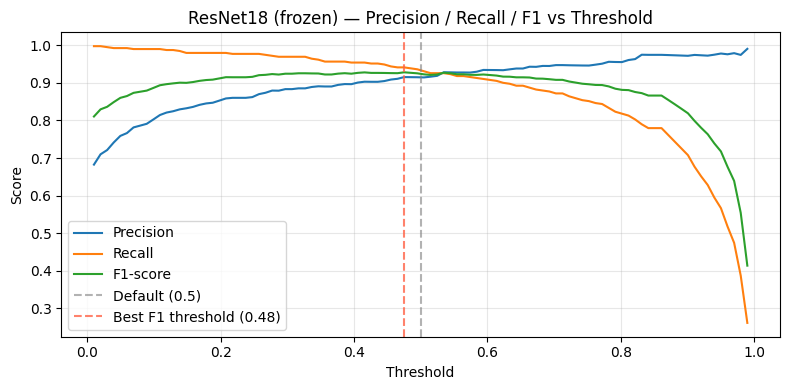

Best F1 threshold: 0.48 → F1: 0.9279
At threshold 0.48:
              precision    recall  f1-score   support

      NORMAL       0.90      0.85      0.88       234
   PNEUMONIA       0.92      0.94      0.93       390

    accuracy                           0.91       624
   macro avg       0.91      0.90      0.90       624
weighted avg       0.91      0.91      0.91       624



In [46]:
from sklearn.metrics import precision_score, recall_score


thresholds = np.linspace(0.01, 0.99, 100)
precision_curve, recall_curve, f1_curve = [], [], []

for t in thresholds:
    preds_t    = (frozen_probs > t).astype(int)
    precision_curve.append(precision_score(frozen_labels, preds_t, zero_division=0))
    recall_curve.append(recall_score(frozen_labels, preds_t, zero_division=0))
    f1_curve.append(f1_score(frozen_labels, preds_t, zero_division=0))

best_t   = thresholds[np.argmax(f1_curve)]
best_f1  = max(f1_curve)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, precision_curve, label="Precision")
ax.plot(thresholds, recall_curve,    label="Recall")
ax.plot(thresholds, f1_curve,        label="F1-score")
ax.axvline(0.5,    color="gray",   linestyle="--", alpha=0.6, label="Default (0.5)")
ax.axvline(best_t, color="tomato", linestyle="--", alpha=0.8, label=f"Best F1 threshold ({best_t:.2f})")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("ResNet18 (frozen) — Precision / Recall / F1 vs Threshold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best F1 threshold: {best_t:.2f} → F1: {best_f1:.4f}")
print(f"At threshold {best_t:.2f}:")
print(classification_report(frozen_labels, (frozen_probs > best_t).astype(int), target_names=class_names))


## 11. Interactive Grad-CAM Explorer


In [40]:
show_class = "ALL"   # @param ["NORMAL", "PNEUMONIA", "ALL"]
show_type  = "ALL"   # @param ["ALL", "CORRECT", "WRONG"]

filtered = []
for i in range(len(test_dataset)):
    _, label = test_dataset[i]
    pred      = frozen_preds[i]
    if show_class != "ALL" and class_names[label] != show_class:
        continue
    if show_type == "CORRECT" and label != pred:
        continue
    if show_type == "WRONG" and label == pred:
        continue
    filtered.append(i)

print(f"Matching: {len(filtered)} images")


Matching: 624 images


Showing 228/624


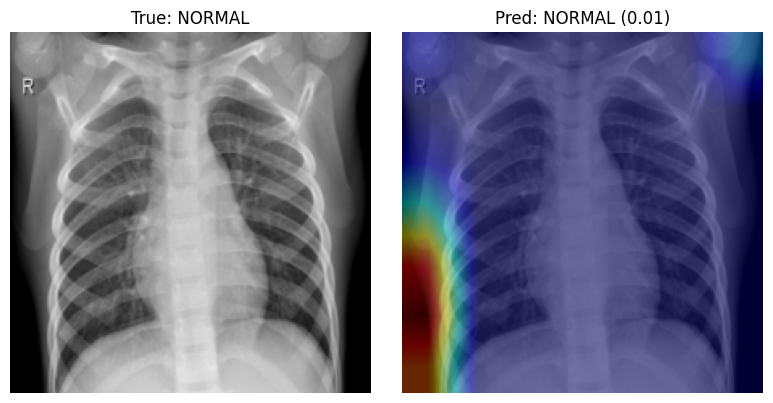

In [41]:
sample_idx = 227  # @param {type:"slider", min:0, max:623, step:1}

clamped   = min(sample_idx, len(filtered) - 1)
idx       = filtered[clamped]
image, label = test_dataset[idx]
inp       = image.unsqueeze(0).to(device)
cam       = gradcam.generate(inp)

img        = np.clip(inv_norm(image).permute(1, 2, 0).numpy(), 0, 1)
cam_r      = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
heatmap    = cv2.cvtColor(cv2.applyColorMap(np.uint8(255 * cam_r), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB) / 255.0
overlay    = 0.5 * img + 0.4 * heatmap

with torch.no_grad():
    prob = torch.sigmoid(resnet_frozen(inp).squeeze()).item()

print(f"Showing {clamped + 1}/{len(filtered)}")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(img);      ax1.set_title(f"True: {class_names[label]}");                 ax1.axis("off")
ax2.imshow(overlay);  ax2.set_title(f"Pred: {class_names[int(prob>0.5)]} ({prob:.2f})"); ax2.axis("off")
plt.tight_layout(); plt.show()


In [42]:
import ipywidgets as widgets
from IPython.display import display, clear_output

all_indices = list(range(len(test_dataset)))
slider = widgets.IntSlider(min=0, max=len(all_indices)-1, step=1, value=0, description="Image:")
output = widgets.Output()

def on_change(change):
    with output:
        clear_output(wait=True)
        idx   = all_indices[change["new"]]
        image, label = test_dataset[idx]
        inp   = image.unsqueeze(0).to(device)
        cam   = gradcam.generate(inp)

        img      = np.clip(inv_norm(image).permute(1, 2, 0).numpy(), 0, 1)
        cam_r    = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
        heatmap  = cv2.cvtColor(cv2.applyColorMap(np.uint8(255 * cam_r), cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB) / 255.0
        overlay  = 0.5 * img + 0.4 * heatmap

        with torch.no_grad():
            prob = torch.sigmoid(resnet_frozen(inp).squeeze()).item()

        print(f"Image {change['new']+1}/{len(all_indices)} | True: {class_names[label]} | Pred: {class_names[int(prob>0.5)]} ({prob:.2f})")
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
        ax1.imshow(img);     ax1.set_title(f"True: {class_names[label]}");                  ax1.axis("off")
        ax2.imshow(overlay); ax2.set_title(f"Pred: {class_names[int(prob>0.5)]} ({prob:.2f})"); ax2.axis("off")
        plt.tight_layout(); plt.show()

slider.observe(on_change, names="value")
display(slider, output)
on_change({"new": 0})


IntSlider(value=0, description='Image:', max=623)

Output()

## 13. Conclusions

Three architectures compared on 624 test images:

| Model | Accuracy | AUC | FP | FN |
|---|---|---|---|---|
| XRayClassifier (CNN) | 0.85 | 0.929 | 78 | 13 |
| ResNet18 — frozen | 0.91 | 0.956 | 34 | 25 |
| ResNet18 — fine-tuned | 0.92 | **0.973** | 47 | **5** |

**Key findings:**

- Transfer learning significantly outperforms training from scratch (AUC +0.04).
- The fine-tuned model achieves the best AUC and lowest false negative rate (FN=5),
  meaning it misses only 5 pneumonia cases out of 390. In a clinical context,
  false negatives are more dangerous than false positives (missed diagnosis vs.
  unnecessary follow-up), which makes fine-tuned the preferred model despite overfitting.
- The frozen model offers a good balance — stable training, AUC 0.956, and faster
  convergence (12 epochs vs ~8 epochs where fine-tuned peaked).
- Grad-CAM confirms the model focuses on lung parenchyma rather than scanner
  borders or artifacts.

**Limitations:** Dataset is ~5k images from a single source. Performance on
out-of-distribution X-rays (different scanners, patient populations) is unknown.
A lower decision threshold (from threshold analysis) can further reduce FN at
the cost of more false alarms.
